# Import packages and data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.optimize import fmin
import torch
import os, glob
import plotly.express as px
import matplotlib.animation as animation
from IPython.display import HTML, Video, display

from indentation.indentationset import IndentationSet
from indentation.processing.find_contact import findContact_minimum, findContact_blackMagic, findContact_blackMagic_CNN
from indentation.processing.signal import do_nothing, crop_afm_temp, crop_start, crop_end
from indentation.processing.calculate_parameters import parameter_youngs_modulus, parameter_defelection_sensitivity
from indentation.processing.plotting import plot_curve_parameters_bar, plot_instance_parameters_bar, plot_mean_force_curves
from indentation.ml.models import ConvClassifier_1, ConvClassifier_2

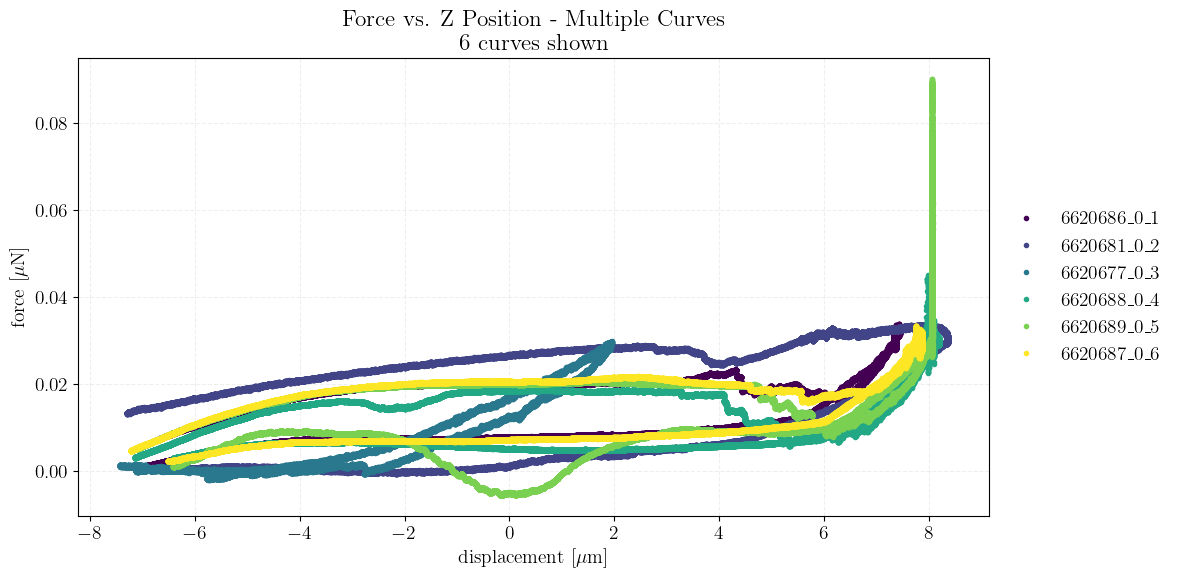

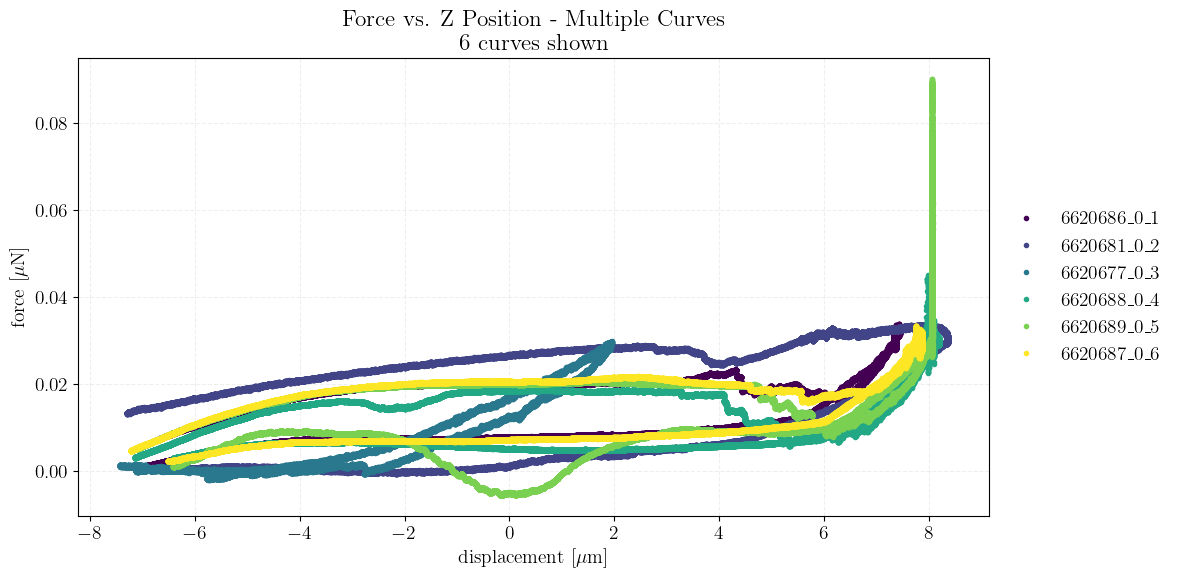

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Force vs. Z Position - Multiple Curves\n6 curves shown'}, xlabel='displacement [$\\mu$m]', ylabel='force [$\\mu$N]'>)

In [13]:
#%matplotlib inline

#paths = glob.glob(r"example_data/14112024_with_Paula/6620389*.txt")
#paths = glob.glob(r"F:\pcameron\3_Experimental\FluidFM\04122024\6620440\*.txt")
paths = glob.glob(r"F:\pcameron\3_Experimental\FluidFM\19122024_with_Paula\*.txt")

fluidfm = IndentationSet(paths[8:], exp_type="fluidfm")

fluidfm.plot_all(linestyle="")
fluidfm.plot_all_raw(linestyle="")


#print(fluidfm.data)

# fluidfm.plot_all(linestyle="")

# fluidfm.delete_curves([1, 2, 3])

# fluidfm.plot_all(linestyle="")

# fluidfm.restore_all()



# plt.figure()
# plt.plot(-fluidfm.data[0]["raw"]["z"], fluidfm.data[0]["raw"]["force"], 'r*')
# plt.show()

# plt.figure()
# plt.plot(fluidfm.data[0]["raw"]["force"], 'r*')
# plt.show()

# plt.figure()
# plt.plot(fluidfm.data[0]["raw"]["z"], 'r*')
# plt.show()

# fig = px.scatter(x=fluidfm.data[0]["raw"]["z"], y=fluidfm.data[0]["raw"]["force"])
# fig.show()

# z = fluidfm.data[0]["raw"]["z"] 
# ix = np.argmax(np.diff(z))
# print(ix)

# f = fluidfm.data[0]["raw"]["force"] 

# f[ix:] = f[ix:][::-1]

# plt.figure()
# plt.plot(f[:-1], 'b*')
# plt.show()

# fig = px.scatter(y=f[:-2])
# fig.show()

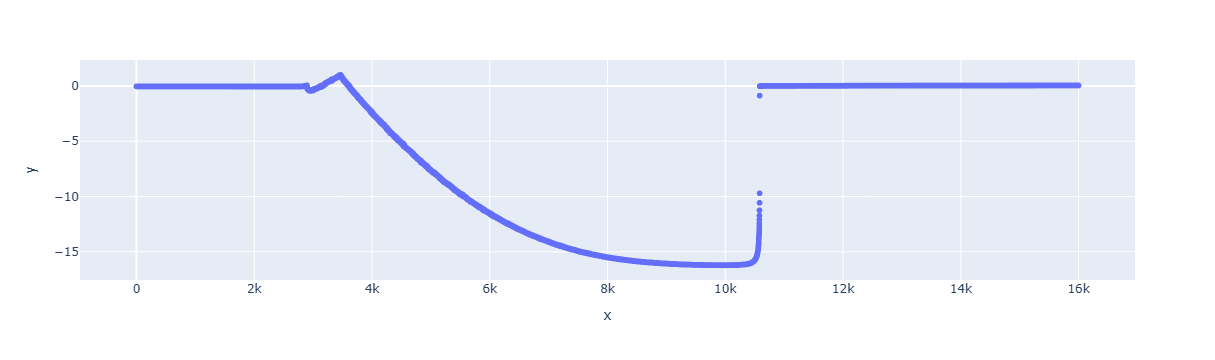

<IPython.core.display.Javascript object>

Animation size has reached 20989090 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


In [10]:
## Animation
i = 0

# Use this to enable interactive plotting inside the notebook
%matplotlib notebook
# vs. notebook

# Parameters (User can modify these)
L = 125              # Length of the beam (m)

# Distance along the length of the beam
x = np.linspace(0, L, 1000)


# Create a custom deflection signal (input data)
# User can replace this with their own deflection data (deflection at the end)
f = fluidfm.data[i]["raw"]["force"] 
z = fluidfm.data[i]["raw"]["z"] 
ix = np.argmax(np.diff(z))
f[ix:] = f[ix:][::-1]
deflection_at_end_signal = f[:-2] / 0.1  # Example: end deflection increases over time
deflection_at_end_signal = deflection_at_end_signal[24000:40000]

fig = px.scatter(y=deflection_at_end_signal)
fig.show()

# Resample the deflection signal to a more suitable frame rate
target_frames = 800  # Choose the number of frames to display
resampled_deflection_signal = np.linspace(0, len(deflection_at_end_signal) - 1, target_frames).astype(int)
downsampled_deflection_signal = deflection_at_end_signal[resampled_deflection_signal]

# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Initial beam (straight line)
line_beam, = ax.plot([0, L], [0, 0], color="black", linewidth=5)  # Beam as a line
line_deflection, = ax.plot([], [], color="blue", linewidth=3, label="Deflected Beam")  # Deflected beam

# Setup plot limits
ax.set_xlim(0, L)
ax.set_ylim(-5, 1)
ax.set_title('Cantilever Beam Deflection Animation')
ax.set_xlabel('Distance from Fixed End (m)')
ax.set_ylabel('Deflection (m)')
ax.axhline(0, color='black', linewidth=0.5)  # x-axis
ax.axvline(0, color='black', linewidth=0.5)  # y-axis
ax.legend()

# Animation function
def animate(i):
    # Get the deflection at the end of the beam (this will change with time)
    deflection_at_end = downsampled_deflection_signal[i]
    
    # Interpolate the deflection profile between the fixed end (0) and the free end (L)
    deflection_at_i = (deflection_at_end) * (x**3) / (L**3)  # Simplified interpolation
    
    # Update the deflection plot
    line_deflection.set_data(x, deflection_at_i)
    
    return line_deflection

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=target_frames, interval=50, repeat=False)

# Display the animation in Jupyter Lab using HTML5 video
#HTML(ani.to_html5_video())  # This uses HTML5 video for proper display in Jupyter Lab

# Save the animation as an HTML5 video file (this step is important for displaying in Jupyter Lab)
HTML(ani.to_jshtml())

ani.save("animation.mp4")

## Animation

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Use this to enable interactive plotting inside the notebook
%matplotlib notebook

# Parameters (User can modify these)
P = 1000           # Applied load (N)
L = 5              # Length of the beam (m)
E = 2.1e11         # Young's Modulus (Pa) for steel
I = 8.33e-6        # Moment of inertia (m^4) for rectangular section

# Distance along the length of the beam
x = np.linspace(0, L, 1000)

# Deflection formula for a point load at the free end of the cantilever
deflection = (P * x**2 * (3*L - x)) / (6 * E * I)

# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(10, 6))

# Initial beam (straight line)
line_beam, = ax.plot([0, L], [0, 0], color="black", linewidth=5)  # Beam as a line
line_deflection, = ax.plot([], [], color="blue", linewidth=3, label="Deflected Beam")  # Deflected beam
load_marker, = ax.plot([], [], 'ro', markersize=10, label="Load Applied (P)")  # Load marker at free end

# Setup plot limits
ax.set_xlim(0, L)
ax.set_ylim(-0.1, 0.1)
ax.set_title('Cantilever Beam Deflection Animation')
ax.set_xlabel('Distance from Fixed End (m)')
ax.set_ylabel('Deflection (m)')
ax.axhline(0, color='black', linewidth=0.5)  # x-axis
ax.axvline(0, color='black', linewidth=0.5)  # y-axis
ax.legend()

# Animation function
def animate(i):
    # The deflection at a given point x
    deflection_at_i = deflection * i / 100  # Progressively animate deflection from 0 to full
    line_deflection.set_data(x, deflection_at_i)
    
    # Move the load marker to the end of the beam (constant position)
    load_marker.set_data([L], [deflection_at_i[-1]])  # Load is always at the free end (x = L)
    
    return line_deflection, load_marker

# Create the animation
ani = animation.FuncAnimation(fig, animate, frames=100, interval=50, repeat=False)

# Display the animation in Jupyter notebook
from IPython.display import HTML
HTML(ani.to_jshtml())  # Convert the animation to JavaScript HTML and display in the notebook


<IPython.core.display.Javascript object>

# Processing data

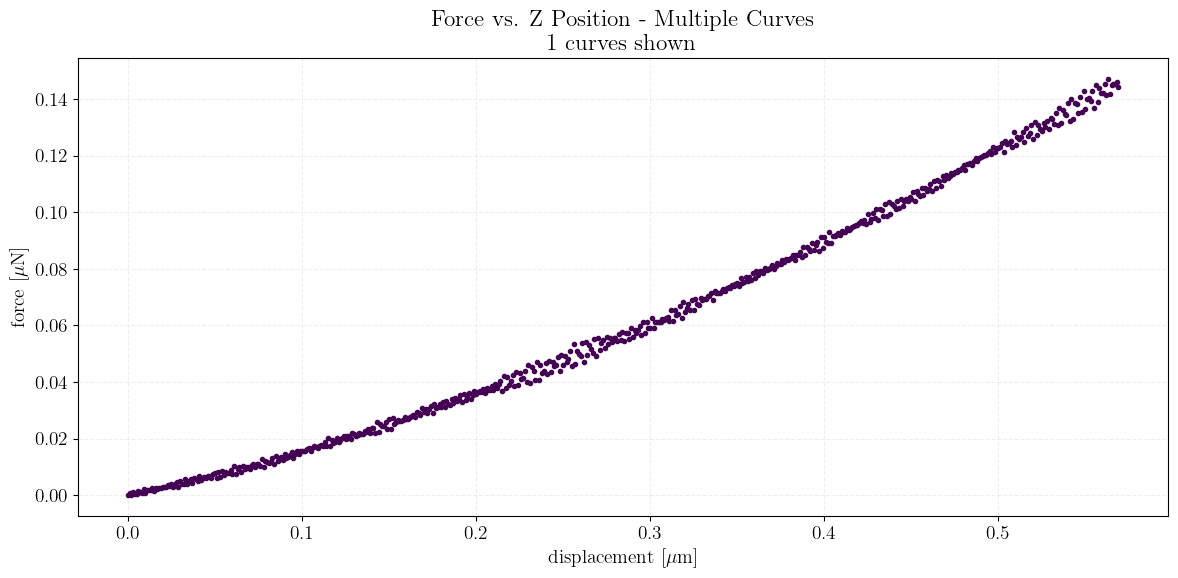

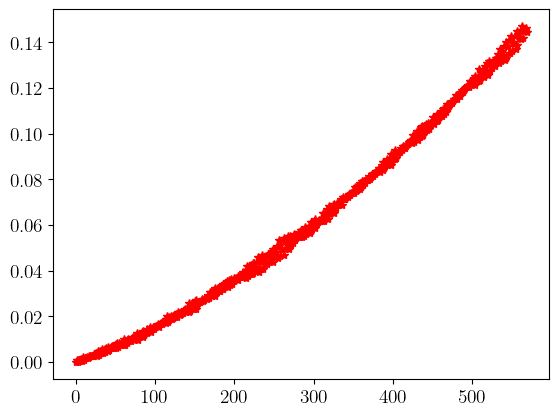

In [95]:
processing_pl = [partial(crop_end, ix_end=10000), crop_afm_temp, findContact_blackMagic]

fluidfm.process_raw(processing_pl)
fluidfm.plot_all(linestyle="")

plt.figure()
plt.plot(fluidfm.data[0]["processed"]["force"], 'r*')
plt.show()

Mean and std: 80.06205201842072 3.982885970324647


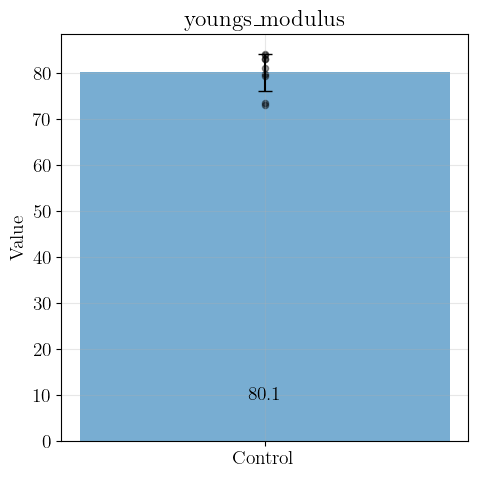

In [82]:
function_arguments = dict(radius=5, nu=0.5, cutoff=100, keyname="youngs_modulus")
fluidfm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
plot_curve_parameters_bar(fluidfm,
                         parameter_names=['youngs_modulus'],
                         labels=['Control'],
                         figsize=(5,5))

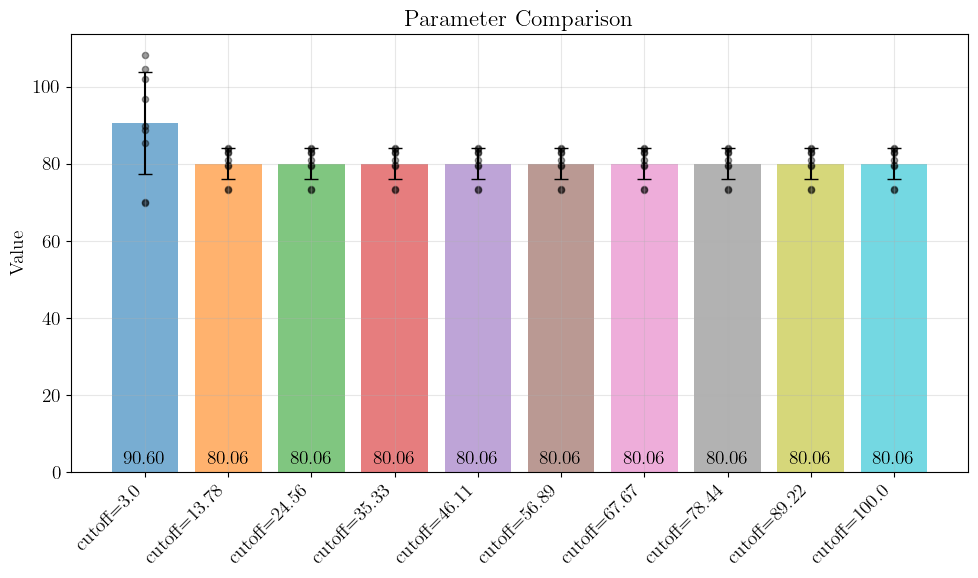

In [77]:
cutoffs = np.linspace(3, 100, 10)

for cutoff in cutoffs:
    function_arguments = dict(radius=5, nu=0.5, cutoff=cutoff, keyname="cutoff="+str(np.round(cutoff, 2)))
    fluidfm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)

plot_instance_parameters_bar(fluidfm,
                         parameter_names=[*["cutoff="+str(np.round(cutoff, 2)) for cutoff in cutoffs]],
                         figsize=(10,6))

58.432449515586725
57.09483081384559
55.269405555368365
58.825003420531104
58.49225511176208
57.7134292374054
58.18200696329751
58.89549846045678
57.84910102597372
Mean and std: 57.86155334491414 1.0621187233312377


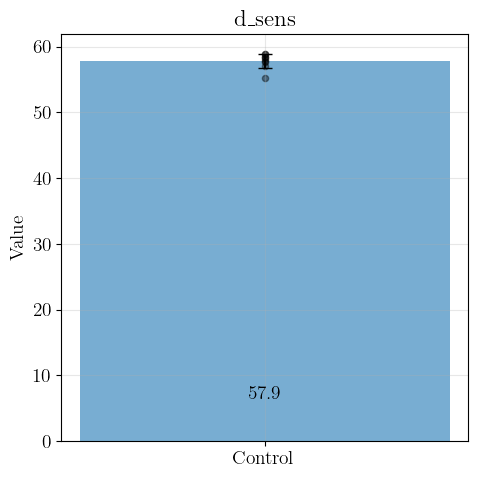

In [35]:
function_arguments = dict(keyname="d_sens")
fluidfm.calculate_curve_parameter(function=parameter_defelection_sensitivity)
plot_curve_parameters_bar(fluidfm,
                         parameter_names=["d_sens"],
                         labels=['Control'],
                         figsize=(5,5))